In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
import plotly.graph_objects as go
import plotly.express as px
import math

In [28]:
df = pd.read_csv('IoTPond10.csv')
df.head()

,created_at,entry_id,TEMPERATURE,TURBIDITY,DISOLVED OXYGEN,pH,AMMONIA,NITRATE,Population,Length,Weight
0,2021-06-25 15:48:59 CET,1,-127.0000,100,0.0,15.45166,0.0,0,50,13.45,27.6
1,2021-06-25 15:49:19 CET,2,-127.0000,100,0.0,15.45166,0.0,0,50,13.45,27.6
2,2021-06-25 15:50:16 CET,3,27.1250,100,0.0,6.01411,0.0,139,50,13.45,27.6
3,2021-06-25 15:51:50 CET,4,27.3125,100,0.0,6.03227,0.0,131,50,13.45,27.6
4,2021-06-25 15:52:10 CET,5,27.2500,100,0.0,6.03681,0.0,133,50,13.45,27.6


In [29]:
print(df.isnull().sum())

created_at         0
entry_id           0
TEMPERATURE        0
TURBIDITY          0
DISOLVED OXYGEN    0
pH                 0
AMMONIA            0
NITRATE            0
Population         0
Length             0
Weight             0
dtype: int64


In [30]:
df.drop(columns=['entry_id','Population'],axis=1,inplace=True)

In [31]:
df.describe()

,TEMPERATURE,TURBIDITY,DISOLVED OXYGEN,pH,AMMONIA,NITRATE,Length,Weight
count,620.000000,620.000000,620.000000,620.000000,620.00000,620.000000,620.000000,620.000000
mean,22.163508,40.361290,2.357571,5.657324,inf,311.558065,27.210543,282.574563
std,27.271589,58.229381,4.398998,2.095430,NaN,391.184946,13.046585,281.105905
min,-127.000000,-97.000000,0.000000,-1.975350,0.00000,0.000000,13.450000,27.600000
25%,26.687500,-13.000000,0.000000,6.018650,0.00000,114.000000,15.571429,45.921394
50%,27.125000,-9.000000,0.000000,6.041350,0.00001,193.000000,24.107143,158.532117
75%,27.312500,100.000000,2.345000,6.163910,0.00522,229.000000,44.549290,689.142900
max,31.687500,100.000000,32.411000,15.451660,inf,2473.000000,44.549290,689.142900


In [32]:
df.columns

Index(['created_at', 'TEMPERATURE', 'TURBIDITY', 'DISOLVED OXYGEN', 'pH',
       'AMMONIA', 'NITRATE', 'Length', 'Weight'],
      dtype='object')

In [33]:
df.shape

(620, 9)

In [34]:
df['created_at'] = pd.to_datetime(df['created_at'], infer_datetime_format=True, utc=True)

In [35]:
df['created_at'] = pd.to_datetime(df.created_at)

#split columns
df["Date"] = df["created_at"].dt.day
df["month"] = df["created_at"].dt.month
df['year']=df['created_at'].dt.year
df['hour']=df['created_at'].dt.hour
df['minutes']=df['created_at'].dt.minute
df['seconds']=df['created_at'].dt.second

In [36]:
df.drop(["created_at"], axis = 1, inplace = True)

In [37]:
 df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df['Date'] = pd.to_numeric(df['Date'])

In [38]:
 df['month'] = pd.to_datetime(df['month'], errors='coerce')

df['month'] = pd.to_numeric(df['month'])

In [39]:
 df['year'] = pd.to_datetime(df['year'], errors='coerce')

df['year'] = pd.to_numeric(df['year'])

In [40]:
df['hour'] = pd.to_datetime(df['hour'], errors='coerce')

df['hour'] = pd.to_numeric(df['hour'])

In [41]:
df['minutes'] = pd.to_datetime(df['minutes'], errors='coerce')

df['minutes'] = pd.to_numeric(df['minutes'])

In [42]:
df['seconds'] = pd.to_datetime(df['seconds'], errors='coerce')

df['seconds'] = pd.to_numeric(df['seconds'])

In [43]:
df.fillna(df.mean(), inplace=True)
df.replace([np.inf, -np.inf], 1e-9, inplace=True)

In [44]:
df.at[0,'TEMPERATURE']=25

In [45]:
for i in range(len(df)):
    if df.loc[i, "TEMPERATURE"] < 20 or df.loc[i, "TEMPERATURE"] > 30:
        df.loc[i, "TEMPERATURE"] = df.loc[i-1, "TEMPERATURE"]

In [46]:
for i in range(1,len(df)):
    if df.loc[i, "TURBIDITY"] < 0:
        df.loc[i, "TURBIDITY"] = df.loc[i-1, "TURBIDITY"]

In [47]:
df.at[0,'DISOLVED OXYGEN']=10

In [48]:
for i in range(1,len(df)):
    if df.loc[i, "DISOLVED OXYGEN"] < 5 or df.loc[i, "DISOLVED OXYGEN"] > 20:
        df.loc[i, "DISOLVED OXYGEN"] = df.loc[i-1, "DISOLVED OXYGEN"]

In [49]:
df.at[0,'pH']=7

In [50]:
for i in range(1,len(df)):
    if df.loc[i, "pH"] < 6 or df.loc[i, "pH"] > 8.5:
        df.loc[i, "pH"] = df.loc[i-1,'pH']

In [51]:
df["NITRATE"] = df["NITRATE"].apply(np.sqrt)

In [52]:
df.describe()

,TEMPERATURE,TURBIDITY,DISOLVED OXYGEN,pH,AMMONIA,NITRATE,Length,Weight,Date,month,year,hour,minutes,seconds
count,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.0,620.000000,620.000000,620.000000
mean,27.043347,89.232258,8.672439,6.353505,214.591499,15.219955,27.210543,282.574563,14.120968,7.430645,2021.0,7.406452,14.533871,14.222581
std,0.826426,23.920930,2.630386,0.509289,2147.730461,8.946514,13.046585,281.105905,6.470004,2.079991,0.0,7.688354,18.215737,18.533787
min,23.937500,36.000000,5.246000,6.005030,0.000000,0.000000,13.450000,27.600000,1.000000,5.000000,2021.0,0.000000,0.000000,0.000000
25%,26.687500,100.000000,6.642000,6.036810,0.000000,10.677078,15.571429,45.921394,10.000000,5.000000,2021.0,0.000000,0.000000,0.000000
50%,27.125000,100.000000,7.883000,6.125330,0.000010,13.892444,24.107143,158.532117,12.000000,7.000000,2021.0,0.000000,0.000000,0.000000
75%,27.312500,100.000000,11.940000,6.350030,0.004900,15.132746,44.549290,689.142900,21.000000,10.000000,2021.0,15.000000,29.000000,29.000000
max,29.500000,100.000000,15.015000,8.483580,35517.878910,49.729267,44.549290,689.142900,30.000000,11.000000,2021.0,21.000000,59.000000,59.000000


In [53]:
df["AMMONIA"] = np.log(df["AMMONIA"]) / 10.0
df["AMMONIA"] = df["AMMONIA"].abs()


In [54]:
df.replace([np.inf, -np.inf], 1e-9, inplace=True)

In [55]:
columns=df.columns.tolist()
columns=columns[-6:]+columns[0:-6]
df=df[columns]

In [56]:
df.head()

,Date,month,year,hour,minutes,seconds,TEMPERATURE,TURBIDITY,DISOLVED OXYGEN,pH,AMMONIA,NITRATE,Length,Weight
0,25,6,2021,15,48,59,25.0000,100,10.0,7.00000,1.000000e-09,0.000000,13.45,27.6
1,25,6,2021,15,49,19,25.0000,100,10.0,7.00000,1.000000e-09,0.000000,13.45,27.6
2,25,6,2021,15,50,16,27.1250,100,10.0,6.01411,1.000000e-09,11.789826,13.45,27.6
3,25,6,2021,15,51,50,27.3125,100,10.0,6.03227,1.000000e-09,11.445523,13.45,27.6
4,25,6,2021,15,52,10,27.2500,100,10.0,6.03681,1.000000e-09,11.532563,13.45,27.6


In [57]:
df.describe()

,Date,month,year,hour,minutes,seconds,TEMPERATURE,TURBIDITY,DISOLVED OXYGEN,pH,AMMONIA,NITRATE,Length,Weight
count,620.000000,620.000000,620.0,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,6.200000e+02,620.000000,620.000000,620.000000
mean,14.120968,7.430645,2021.0,7.406452,14.533871,14.222581,27.043347,89.232258,8.672439,6.353505,3.763261e-01,15.219955,27.210543,282.574563
std,6.470004,2.079991,0.0,7.688354,18.215737,18.533787,0.826426,23.920930,2.630386,0.509289,4.342120e-01,8.946514,13.046585,281.105905
min,1.000000,5.000000,2021.0,0.000000,0.000000,0.000000,23.937500,36.000000,5.246000,6.005030,1.000000e-09,0.000000,13.450000,27.600000
25%,10.000000,5.000000,2021.0,0.000000,0.000000,0.000000,26.687500,100.000000,6.642000,6.036810,1.000000e-09,10.677078,15.571429,45.921394
50%,12.000000,7.000000,2021.0,0.000000,0.000000,0.000000,27.125000,100.000000,7.883000,6.125330,4.535394e-01,13.892444,24.107143,158.532117
75%,21.000000,10.000000,2021.0,15.000000,29.000000,29.000000,27.312500,100.000000,11.940000,6.350030,5.714605e-01,15.132746,44.549290,689.142900
max,30.000000,11.000000,2021.0,21.000000,59.000000,59.000000,29.500000,100.000000,15.015000,8.483580,2.072327e+00,49.729267,44.549290,689.142900


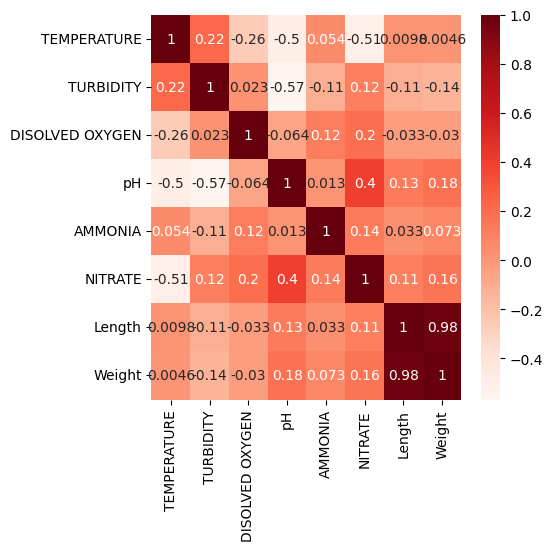

In [58]:
#creating a heatmap to show the correlation between the features
plt.figure(figsize=(5, 5))
x=df.iloc[:,6:]
cor = x.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.Reds)
plt.show()

In [60]:
df.to_csv('pp10.csv', index=False)